# Method Benchmark of Basic Investment Model

Compares **PFI** (dense grid benchmark), **LR**, **ER**, **BRM**, and
**SHAC** under a shared **convergence target** instead of a shared compute
budget.

In this frictionless baseline, the environment has an **analytical solution**.
So the main correctness metric is now the direct **eval-state k' mean absolute
error** against the analytical policy, with PFI included as one more method in
that direct comparison.


---
# Section 0: Setup


In [1]:
import sys, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
from dataclasses import replace

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _REPO_ROOT = Path(_nb_file).parent.parent
else:
    _REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

from src.v2.evaluation import (
    build_action_grid_policy,
    evaluate_lifetime_reward,
    evaluate_policy_mae,
    load_manifest,
    load_method_bundle,
    load_solver_bundle,
    prepare_evaluation_run,
    restore_selected_snapshot,
    save_figure,
    save_manifest_sections,
    save_method_bundle,
    save_solver_bundle,
    save_plot_inputs,
    save_summary_rows,
)
from src.v2.data.generator import DataGenerator, DataGeneratorConfig
from src.v2.environments.basic_investment import (
    BasicInvestmentEnv, EconomicParams, ShockParams,
    compute_frictionless_policy,
)
from src.v2.networks.policy import PolicyNetwork
from src.v2.networks.state_value import StateValueNetwork
from src.v2.solvers import solve_pfi, PFIConfig, GridConfig
from src.v2.trainers.brm import train_brm
from src.v2.trainers.config import LRConfig, ERConfig, BRMConfig, SHACConfig
from src.v2.trainers.core import evaluate_euler_residual
from src.v2.trainers.er import train_er
from src.v2.trainers.lr import train_lr
from src.v2.trainers.shac import train_shac
from src.v2.utils.seeding import fold_in_seed, seed_runtime

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow 2.16.2
GPU available: False


In [2]:
# Run control
# EXPERIMENT_NAME identifies the folder under results_root for all runs of
# this notebook. Update it when forking to a new problem or environment.
EXPERIMENT_NAME = "basic_frictionless"

# RESULTS_ROOT resolves relative to this notebook file, not the Jupyter CWD.
# VSCode sets __vsc_ipynb_file__; standard Jupyter falls back to parent of cwd.
_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    from pathlib import Path as _Path
    _REPO_ROOT = _Path(_nb_file).parent.parent
else:
    from pathlib import Path as _Path
    _REPO_ROOT = _Path.cwd().parent  # fallback: assume cwd is docs/
RESULTS_ROOT = str(_REPO_ROOT / "outputs" / "notebooks")

SAVE_RUN     = False
LOAD_RUN_DIR = None      # set to e.g. "outputs/notebooks/basic_frictionless/latest"
RUN_TAG      = "part1-benchmark"      # None, if set, becomes the run folder name (e.g. "paper-final")
RECOMPUTE_LOADED_METRICS = False

# Methods to run. Remove entries to skip. PFI always runs as the benchmark.
TRAINED_METHODS = ["LR", "ER", "SHAC"]

METHOD_COLORS = {
    "PFI":  "red",
    "LR":   "steelblue",
    "ER":   "darkorange",
    "SHAC":  "seagreen",
}

RUN = prepare_evaluation_run(
    EXPERIMENT_NAME,
    save_run=SAVE_RUN,
    load_run_dir=LOAD_RUN_DIR,
    results_root=RESULTS_ROOT,
    run_tag=RUN_TAG,
)
print(f"Mode: {RUN['mode']} | Methods: {TRAINED_METHODS}")
if RUN["run_dir"] is not None:
    print(f"Run dir: {RUN['run_dir']}")


Mode: memory | Methods: ['LR', 'ER', 'SHAC']


In [3]:
# Training profile: controls only computational cost.
# Switch to "FULL" for paper-quality results.
# Data, convergence criteria, and economic params are identical across profiles.
PROFILE = "FAST_DEBUG"

_PROFILES = {
    "FAST_DEBUG": dict(
        N_LAYERS=2, N_NEURONS=32,
        N_STEPS=300,  EVAL_INTERVAL=50,
        PFI_EXO_SIZE=50,  PFI_ENDO_SIZE=50,  PFI_ACT_SIZE=100,
        PFI_MAX_ITER=100, PFI_EVAL_STEPS=100,
    ),
    "FULL": dict(
        N_LAYERS=4, N_NEURONS=128,
        N_STEPS=4000, EVAL_INTERVAL=100,
        PFI_EXO_SIZE=100, PFI_ENDO_SIZE=100, PFI_ACT_SIZE=500,
        PFI_MAX_ITER=200, PFI_EVAL_STEPS=200,
    ),
}
assert PROFILE in _PROFILES, f"Unknown profile: {PROFILE!r}. Choose from {list(_PROFILES)}"
_p = _PROFILES[PROFILE]
print(f"Profile: {PROFILE} | net={_p['N_LAYERS']}L x {_p['N_NEURONS']}N | "
      f"cap={_p['N_STEPS']:,} steps | PFI ({_p['PFI_EXO_SIZE']}x{_p['PFI_ENDO_SIZE']}x{_p['PFI_ACT_SIZE']})")


Profile: FAST_DEBUG | net=2L x 32N | cap=300 steps | PFI (50x50x100)


In [4]:
# From profile: network size, training budget, PFI grid resolution.
N_LAYERS       = _p["N_LAYERS"]
N_NEURONS      = _p["N_NEURONS"]
N_STEPS        = _p["N_STEPS"]
EVAL_INTERVAL  = _p["EVAL_INTERVAL"]
PFI_EXO_SIZE   = _p["PFI_EXO_SIZE"]
PFI_ENDO_SIZE  = _p["PFI_ENDO_SIZE"]
PFI_ACT_SIZE   = _p["PFI_ACT_SIZE"]
PFI_MAX_ITER   = _p["PFI_MAX_ITER"]
PFI_EVAL_STEPS = _p["PFI_EVAL_STEPS"]

# Fixed regardless of profile: change these to study a different problem.
#
# ── Early stopping ──
# Two rules, checked in order at each eval checkpoint (first to fire wins):
#
#   1. THRESHOLD (convergence):  metric <= CONVERGENCE_THRESHOLD for
#      THRESHOLD_PATIENCE consecutive evals.   stop_reason = "converged"
#
#   2. PLATEAU (fallback, only checked when threshold fails):
#      metric has not improved for PLATEAU_PATIENCE consecutive evals.
#      stop_reason = "plateau"
#      Set to None to disable.
#
# CONVERGENCE_MONITOR: "policy_mae" | "euler_residual_val" | "auto"

CONVERGENCE_MONITOR   = "policy_mae"  # explicit for this notebook (analytical solution available)
CONVERGENCE_THRESHOLD = 2.0
THRESHOLD_PATIENCE    = 2      # consecutive evals satisfying threshold
PLATEAU_PATIENCE      = None   # evals w/o improvement (None = disabled)
N_PATHS              = 5000
HORIZON_DATA         = 256
MASTER_SEED          = (20, 26)
STRICT_REPRODUCIBILITY = False
LR_HORIZON           = 32

EVAL_HORIZON         = 128      # Horizon for evaluating lifetime reward on validation set
EVAL_TRAJ_SAMPLES    = 2000     # Number of trajectories for lifetime reward eval on validation set
ANALYTIC_GAP_SAMPLES = 20000    # Policy MAE against analytic solution

print(f"Threshold stopping: {CONVERGENCE_MONITOR} <= {CONVERGENCE_THRESHOLD} for {THRESHOLD_PATIENCE} evals | cap={N_STEPS:,} steps")
print(f"Plateau stopping:   {'disabled' if PLATEAU_PATIENCE is None else f'{PLATEAU_PATIENCE} evals w/o improvement'}")
print(f"Data: N_PATHS={N_PATHS}, HORIZON={HORIZON_DATA}, MASTER_SEED={MASTER_SEED}")
print(f"PFI grid: z={PFI_EXO_SIZE}, k={PFI_ENDO_SIZE}, I={PFI_ACT_SIZE}")

Threshold stopping: policy_mae <= 2.0 for 2 evals | cap=300 steps
Plateau stopping:   disabled
Data: N_PATHS=5000, HORIZON=256, MASTER_SEED=(20, 26)
PFI grid: z=50, k=50, I=100


---
# Section 1: Environment & Data


In [5]:
baseline_params = EconomicParams(
    interest_rate=0.04,
    depreciation_rate=0.15,
    production_elasticity=0.7,
    cost_convex=0.0,
    cost_fixed=0.0,
)
shock_params = ShockParams(mu=0.0, rho=0.7, sigma=0.1)

env = BasicInvestmentEnv(econ_params=baseline_params, shock_params=shock_params)

print("BasicInvestmentEnv (frictionless baseline)")
print(f"  State dim:  {env.state_dim()}   (endo={env.endo_dim()}, exo={env.exo_dim()})")
print(f"  Action dim: {env.action_dim()}")
print(f"  Discount:   {env.discount():.4f}")
print(f"  k in [{env.k_min:.2f}, {env.k_max:.2f}]")
print(f"  z in [{env.z_min:.3f}, {env.z_max:.3f}]")


BasicInvestmentEnv (frictionless baseline)
  State dim:  2   (endo=1, exo=1)
  Action dim: 1
  Discount:   0.9615
  k in [19.63, 471.20]
  z in [0.657, 1.522]


In [6]:
# Data is always regenerated from MASTER_SEED — fast (a few seconds) and avoids
# storing large binary files in the run folder.
gen_config = DataGeneratorConfig(
    n_paths=N_PATHS,
    horizon=HORIZON_DATA,
    master_seed=MASTER_SEED,
)
gen = DataGenerator(env, gen_config)

train_traj = gen.get_trajectory_dataset("train")
train_flat = gen.get_flattened_dataset("train")
val_traj   = gen.get_trajectory_dataset("val")
val_flat   = gen.get_flattened_dataset("val")

# Save only reproducibility metadata — the data itself is not persisted.
save_manifest_sections(
    RUN,
    setup={
        "master_seed":              list(MASTER_SEED),
        "strict_reproducibility":   STRICT_REPRODUCIBILITY,
    },
    data={
        "n_paths":     N_PATHS,
        "horizon":     HORIZON_DATA,
        "master_seed": list(MASTER_SEED),
    },
    benchmark={
        "convergence_monitor":   CONVERGENCE_MONITOR,
        "convergence_threshold": CONVERGENCE_THRESHOLD,
        "threshold_patience":    THRESHOLD_PATIENCE,
        "plateau_patience":      PLATEAU_PATIENCE,
        "n_steps":            N_STEPS,
        "eval_interval":      EVAL_INTERVAL,
        "eval_horizon":       EVAL_HORIZON,
        "eval_traj_samples":  EVAL_TRAJ_SAMPLES,
        "analytic_gap_samples": ANALYTIC_GAP_SAMPLES,
        "pfi_grid":           [PFI_EXO_SIZE, PFI_ENDO_SIZE, PFI_ACT_SIZE],
        "pfi_max_iter":       PFI_MAX_ITER,
        "pfi_eval_steps":     PFI_EVAL_STEPS,
    },
    env={"econ_params": baseline_params, "shock_params": shock_params},
)

print(f"Training trajectories: {train_traj['s_endo_0'].shape[0]} paths")
print(f"Training flat states:  {train_flat['s_endo'].shape[0]}")
print(f"Validation trajectories: {val_traj['s_endo_0'].shape[0]} paths")
print(f"Validation flat states:  {val_flat['s_endo'].shape[0]}")

Training trajectories: 5000 paths
Training flat states:  1280000
Validation trajectories: 5000 paths
Validation flat states:  1280000


---
# Section 2: Helpers

Network factories, slope-based calibration, analytical policy evaluation,
post-hoc checkpoint evaluation, and policy validation plots.


In [7]:
# Network factories

def derived_seed(*tokens):
    """Derive a deterministic child seed pair from MASTER_SEED for network init."""
    return fold_in_seed(MASTER_SEED, *tokens)


def make_policy_net(env, name="policy", seed=None):
    net = PolicyNetwork(
        state_dim=env.state_dim(),
        action_dim=env.action_dim(),
        **env.action_spec(),
        n_layers=N_LAYERS,
        n_neurons=N_NEURONS,
        seed=seed,
        name=name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def make_value_net(env, name="value_net", seed=None):
    net = StateValueNetwork(
        state_dim=env.state_dim(),
        n_layers=N_LAYERS,
        n_neurons=N_NEURONS,
        seed=seed,
        name=name,
    )
    net(tf.zeros((1, env.state_dim())))
    return net


def build_pfi_policy(result):
    """Wrap a grid-solver result as a callable policy (InterpolatedGridPolicy)."""
    return build_action_grid_policy(result, env.action_dim())


def take_dataset_head(dataset, n):
    return {k: v[:n] for k, v in dataset.items()}


In [8]:
# Evaluation utilities

def analytic_kprime(z):
    """Frictionless optimal next-period capital k'*(z), clipped to grid bounds."""
    return np.clip(
        compute_frictionless_policy(z, baseline_params, shock_params),
        env.k_min,
        env.k_max,
    )

def make_eval_callback(eval_env, eval_flat, eval_traj, analytic_dataset):
    def _callback(step, _env, policy, value_net, val_dataset):
        del step, value_net, val_dataset
        metrics = {
            "euler_residual_val":  evaluate_euler_residual(eval_env, policy, eval_flat),
            "lifetime_reward_val": evaluate_lifetime_reward(eval_env, policy, eval_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES),
        }
        try:
            metrics["policy_mae"] = evaluate_policy_mae(eval_env, policy, analytic_dataset)
        except NotImplementedError:
            pass
        return metrics
    return _callback


def make_pfi_eval_callback(eval_env, eval_flat, eval_traj, analytic_dataset):
    """Eval callback for PFI/VFI solvers; wraps partial_result into a grid policy."""
    def _callback(iteration, partial_result):
        policy = build_pfi_policy(partial_result)
        metrics = {
            "euler_residual_val":  evaluate_euler_residual(eval_env, policy, eval_flat),
            "lifetime_reward_val": evaluate_lifetime_reward(eval_env, policy, eval_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES),
        }
        try:
            metrics["policy_mae"] = evaluate_policy_mae(eval_env, policy, analytic_dataset)
        except NotImplementedError:
            pass
        return metrics
    return _callback


def auto_monitor(eval_env):
    """Return the highest-priority available convergence metric."""
    try:
        eval_env.analytical_policy(
            eval_env.sample_initial_states(1, seed=tf.constant([0, 0])))
        return "policy_mae"
    except NotImplementedError:
        pass
    try:
        eval_env.euler_residual(
            *[eval_env.sample_initial_states(1, seed=tf.constant([0, 0]))] * 4)
        return "euler_residual_val"
    except NotImplementedError:
        pass
    return "lifetime_reward_val"


In [9]:
# Checkpoint & plotting helpers

def persist_figure(fig, filename):
    save_figure(RUN, fig, filename)


def persist_method(name):
    entry = results[name]
    save_method_bundle(
        RUN, name,
        result=entry.get("result"),
        weight_history=entry.get("weight_history"),
        checkpoint_metrics=entry.get("checkpoint_metrics"),
        selected=entry.get("selected"),
        extra_sections={"name": entry.get("name", name)},
    )


def load_saved_method(name):
    entry  = load_method_bundle(RUN, name)
    policy = make_policy_net(env, name=f"policy_{name.lower()}",
                         seed=derived_seed("training", name, "policy"))
    if entry.get("selected") is not None:
        restore_selected_snapshot(policy, entry["weight_history"],
                                  entry["selected"]["selected_step"])
    elif entry["weight_history"]:
        policy.set_weights(entry["weight_history"][-1][1])
    entry["policy"] = policy
    entry["name"]   = entry["result"].get("name", name)
    if entry.get("checkpoint_metrics") is not None:
        entry["checkpoint_index"] = {
            int(step): idx
            for idx, step in enumerate(entry["checkpoint_metrics"]["step"])
        }
    return entry


def evaluate_snapshots(name, results_dict, env, val_traj, analytic_dataset):
    """Read checkpoint metrics directly from the trainer history (no re-evaluation)."""
    del env, val_traj, analytic_dataset
    entry   = results_dict[name]
    history = entry["result"]["history"]
    metrics = {
        key: list(history[key])
        for key in ["step", "elapsed_sec",
                    "euler_residual_val", "lifetime_reward_val", "policy_mae"]
        if key in history
    }
    entry["checkpoint_metrics"] = metrics
    entry["checkpoint_index"]   = {step: idx for idx, step in enumerate(metrics["step"])}
    print(f"  {name}: {len(metrics['step'])} checkpoint metrics from trainer history")


def select_checkpoint(name, results_dict):
    """Select and restore the best policy snapshot.

    Convergence (binary):
      converged     - stop_step (last confirmed hit <= threshold, after patience)
      not_converged - best_step (lowest metric seen; restored for diagnostics)
    """
    entry       = results_dict[name]
    result      = entry["result"]
    metrics     = entry["checkpoint_metrics"]
    step_to_idx = entry["checkpoint_index"]

    if result["converged"] and result["stop_step"] in step_to_idx:
        selected_step, status = result["stop_step"], "converged"
    elif result["best_step"] is not None and result["best_step"] in step_to_idx:
        selected_step, status = result["best_step"], "not_converged"
    else:
        entry["selected"] = {
            "status": "no_data", "selected_step": None,
            "selected_euler": float("nan"), "selected_value": float("nan"),
            "selected_analytic_mae": float("nan"),
            "first_hit_step": result.get("threshold_step"),
            "first_hit_elapsed_sec": result.get("threshold_elapsed_sec"),
            "stop_step": result.get("stop_step"),
            "stop_elapsed_sec": result.get("stop_elapsed_sec"),
            "wall_time_sec": result["wall_time_sec"],
            "stop_reason": result.get("stop_reason"),
        }
        return

    idx = step_to_idx[selected_step]
    entry["selected"] = {
        "status": status,
        "selected_step": selected_step,
        "selected_elapsed_sec": metrics["elapsed_sec"][idx],
        "selected_euler": metrics["euler_residual_val"][idx],
        "selected_value": metrics["lifetime_reward_val"][idx],
        "selected_analytic_mae": metrics["policy_mae"][idx],
        "first_hit_step": result.get("threshold_step"),
        "first_hit_elapsed_sec": result.get("threshold_elapsed_sec"),
        "stop_step": result.get("stop_step"),
        "stop_elapsed_sec": result.get("stop_elapsed_sec"),
        "wall_time_sec": result["wall_time_sec"],
        "stop_reason": result.get("stop_reason"),
    }
    for step, weights in entry["weight_history"]:
        if step == selected_step:
            entry["policy"].set_weights(weights)
            entry["selected_weights"] = weights
            return
    raise ValueError(f"{name}: selected step {selected_step} missing from weight history")


def get_policy_slices(policy):
    """Compute k'(z) at k=k* and k'(k) at z=E[z] via env.endogenous_transition."""
    a_z = policy(s_at_kstar, training=False)
    a_k = policy(s_at_zmean, training=False)
    kp_z = env.endogenous_transition(
        s_at_kstar[:, :env.endo_dim()], a_z, s_at_kstar[:, env.endo_dim():]
    ).numpy().reshape(-1)
    kp_k = env.endogenous_transition(
        s_at_zmean[:, :env.endo_dim()], a_k, s_at_zmean[:, env.endo_dim():]
    ).numpy().reshape(-1)
    return kp_z, kp_k


def validate_single(label, kp_z, kp_k, color, benchmark_kpz, benchmark_kpk,
                    save_name=None):
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    mae  = np.mean(np.abs(kp_z - kp_analytical_z))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(z_grid, kp_analytical_z, "k--", lw=2, alpha=0.8, label="Analytical")
    axes[0].plot(z_grid, benchmark_kpz, color=METHOD_COLORS["PFI"],
                 lw=1.5, ls=":", alpha=0.9, label="PFI")
    axes[0].plot(z_grid, kp_z, color=color, lw=1.5, label=label)
    axes[0].set_title(f"k'(z) at k=k*   corr={corr:.4f}, MAE={mae:.2f}", fontweight="bold")
    axes[0].set_xlabel("Productivity z"); axes[0].set_ylabel("Next capital k'")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].axhline(kp_analytical_ss, color="k", ls="--", lw=2, alpha=0.8,
                    label=f"Analytical k'={kp_analytical_ss:.1f}")
    axes[1].plot(k_grid, benchmark_kpk, color=METHOD_COLORS["PFI"],
                 lw=1.5, ls=":", alpha=0.9, label="PFI")
    axes[1].plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.5, label="45 line")
    axes[1].plot(k_grid, kp_k, color=color, lw=1.5, label=label)
    axes[1].set_title("k'(k) at z=E[z]   (should be flat)", fontweight="bold")
    axes[1].set_xlabel("Current capital k"); axes[1].set_ylabel("Next capital k'")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{label} \u2014 Selected Checkpoint Validation",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    persist_figure(fig, save_name)
    plt.show()


def add_hit_marker(ax, entry, y_values, color, label):
    first_hit_step = entry["result"].get("threshold_step")
    if first_hit_step is None:
        return
    idx = entry["checkpoint_index"].get(first_hit_step)
    if idx is None:
        return
    ax.scatter(
        entry["checkpoint_metrics"]["elapsed_sec"][idx],
        y_values[idx],
        s=60, facecolors="none", edgecolors=color, linewidths=1.8, label=label,
    )

In [10]:
# accuracy_flat is a head slice of val_flat — no need to persist it.
accuracy_flat = take_dataset_head(val_flat, ANALYTIC_GAP_SAMPLES)

n_grid = 500
z_grid = np.linspace(float(env.z_min), float(env.z_max), n_grid)
k_grid = np.linspace(float(env.k_min), float(env.k_max), n_grid)
k_star = float(env.k_star)
z_mean = float(np.exp(shock_params.mu))
delta  = baseline_params.delta

kp_analytical_z  = analytic_kprime(z_grid)
kp_analytical_ss = analytic_kprime(np.array([z_mean]))[0]

s_at_kstar = tf.constant(np.column_stack([np.full(n_grid, k_star), z_grid]),  dtype=tf.float32)
s_at_zmean = tf.constant(np.column_stack([k_grid, np.full(n_grid, z_mean)]), dtype=tf.float32)

save_plot_inputs(
    RUN, "slice_grids",
    {
        "z_grid": z_grid, "k_grid": k_grid,
        "k_star": [k_star], "z_mean": [z_mean],
        "kp_analytical_z": kp_analytical_z,
        "kp_analytical_ss": [kp_analytical_ss],
    },
)

analytic_value  = evaluate_lifetime_reward(env, env.analytical_policy, val_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES)


---
# Section 4: PFI Benchmark

Use one manually refined dense PFI benchmark in this notebook. The grid is
increased directly to a higher-resolution setting and then checked against the
analytical solution, rather than running a full frontier sweep inside the main
benchmark notebook.


In [11]:
print("PFI benchmark note: this notebook uses one manually refined dense grid rather than a frontier sweep.")
print("The current default is increased directly to a high-resolution baseline and validated against analytical slices.")

gc = GridConfig(
    exo_sizes=[PFI_EXO_SIZE],
    endo_sizes=[PFI_ENDO_SIZE],
    action_sizes=[PFI_ACT_SIZE],
)

if RUN["mode"] == "load":
    pfi_bundle = load_solver_bundle(RUN)
    result_pfi = pfi_bundle["result"]
    pfi_summary = pfi_bundle["summary"]
    pfi_wall = pfi_summary["wall_time_sec"]
    pfi_policy = build_pfi_policy(result_pfi)
    pfi_euler = pfi_summary["selected_euler"]
    pfi_value = pfi_summary["selected_value"]
    pfi_analytic_mae = pfi_summary["selected_analytic_mae"]
    print(f"Loaded PFI bundle from {RUN['run_dir']}")
else:
    t0 = time.perf_counter()
    pfi_eval_cb = make_pfi_eval_callback(env, val_flat, val_traj, accuracy_flat)
    result_pfi = solve_pfi(env, train_flat, PFIConfig(grid=gc, max_iter=PFI_MAX_ITER, eval_steps=PFI_EVAL_STEPS),
                          eval_callback=pfi_eval_cb)
    pfi_wall = time.perf_counter() - t0
    pfi_policy = build_pfi_policy(result_pfi)
    pfi_euler = evaluate_euler_residual(env, pfi_policy, val_flat)
    pfi_value = evaluate_lifetime_reward(env, pfi_policy, val_traj, horizon=EVAL_HORIZON, n_samples=EVAL_TRAJ_SAMPLES)
    pfi_analytic_mae = evaluate_policy_mae(env, pfi_policy, accuracy_flat)
    save_solver_bundle(
        RUN,
        result_pfi,
        summary={
            "wall_time_sec": pfi_wall,
            "selected_euler": pfi_euler,
            "selected_value": pfi_value,
            "selected_analytic_mae": pfi_analytic_mae,
            "grid": [PFI_EXO_SIZE, PFI_ENDO_SIZE, PFI_ACT_SIZE],
        },
    )
    save_manifest_sections(RUN, pfi={"grid": [PFI_EXO_SIZE, PFI_ENDO_SIZE, PFI_ACT_SIZE]})

pfi_kpz, pfi_kpk = get_policy_slices(pfi_policy)

print(f"PFI grid: z={PFI_EXO_SIZE}, k={PFI_ENDO_SIZE}, I={PFI_ACT_SIZE}")
print(f"PFI: {result_pfi['n_iter']} iterations, {pfi_wall:.1f}s")
print(f"PFI eval Euler residual:   {pfi_euler:.6f}")
print(f"PFI lifetime reward val:   {pfi_value:.2f}")
print(f"PFI policy MAE:            {pfi_analytic_mae:.4f}")

results = {
    "PFI": {
        "name": "PFI",
        "result": result_pfi,
        "policy": pfi_policy,
        "wall_time_sec": pfi_wall,
        "selected": {
            "status": "grid-benchmark",
            "selected_step": None,
            "selected_elapsed_sec": pfi_wall,
            "selected_euler": pfi_euler,
            "selected_value": pfi_value,
            "selected_analytic_mae": pfi_analytic_mae,
            "first_hit_step": None,
            "first_hit_elapsed_sec": None,
            "stop_step": None,
            "stop_elapsed_sec": pfi_wall,
            "wall_time_sec": pfi_wall,
            "stop_reason": "benchmark",
        },
    }
}


PFI benchmark note: this notebook uses one manually refined dense grid rather than a frontier sweep.
The current default is increased directly to a high-resolution baseline and validated against analytical slices.
PFI converged: 4 policy updates
PFI grid: z=50, k=50, I=100
PFI: 4 iterations, 15.3s
PFI eval Euler residual:   0.014596
PFI lifetime reward val:   425.86
PFI policy MAE:            1.3138


---
# Section 5: Training (Threshold-Driven)


In [12]:
# Trainer configurations
# Edit here to tune each method. Common stopping parameters come from the
# Parameters cell above. weight_history is attached per training run below.

_monitor = auto_monitor(env) if CONVERGENCE_MONITOR == "auto" else CONVERGENCE_MONITOR

_common = dict(
    master_seed=MASTER_SEED,
    strict_reproducibility=STRICT_REPRODUCIBILITY,
    n_steps=N_STEPS,
    eval_interval=EVAL_INTERVAL,
    monitor=_monitor,
    mode="min",
    threshold=CONVERGENCE_THRESHOLD,
    threshold_patience=THRESHOLD_PATIENCE,
    plateau_patience=PLATEAU_PATIENCE,
)

lr_config = LRConfig(
    **_common,
    horizon=LR_HORIZON,
    terminal_value=True,
)

er_config = ERConfig(**_common)

brm_config = BRMConfig(
    **_common,
    br_scale=1.0 / env.reward_scale(),
    warm_start_epochs=0,        # set > 0 to warm-start the critic on analytical V
)

shac_config = SHACConfig(**_common)

print("Trainer configs:")
for cfg in [lr_config, er_config, brm_config, shac_config]:
    _tp = f"threshold_patience={cfg.threshold_patience}"
    _pp = f"plateau_patience={cfg.plateau_patience}" if cfg.plateau_patience else "plateau=off"
    print(f"  {type(cfg).__name__:<12} n_steps={cfg.n_steps:,}  "
          f"eval_interval={cfg.eval_interval}  {_tp}  {_pp}")

Trainer configs:
  LRConfig     n_steps=300  eval_interval=50  threshold_patience=2  plateau=off
  ERConfig     n_steps=300  eval_interval=50  threshold_patience=2  plateau=off
  BRMConfig    n_steps=300  eval_interval=50  threshold_patience=2  plateau=off
  SHACConfig   n_steps=300  eval_interval=50  threshold_patience=2  plateau=off


In [13]:
# Load all selected methods when resuming a saved run.
if RUN["mode"] == "load":
    for name in TRAINED_METHODS:
        results[name] = load_saved_method(name)
    print(f"Loaded from {RUN['run_dir']}: {TRAINED_METHODS}")


In [14]:
if "LR" in TRAINED_METHODS and RUN["mode"] != "load":
    weight_history_lr = []
    res_lr = train_lr(
        env,
        make_policy_net(env, "policy_lr", seed=derived_seed("training", "LR", "policy")),
        train_traj, val_flat,
        config=replace(lr_config, weight_history=weight_history_lr),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["LR"] = {
        "name": "LR",
        "result": res_lr,
        "policy": res_lr["policy"],
        "weight_history": weight_history_lr,
    }
    persist_method("LR")


LR step     0 | loss=-363.8868 | policy_mae=139.292236 | elapsed=7.5s
LR step    50 | loss=-425.7061 | policy_mae=122.847298 | elapsed=9.0s
LR step   100 | loss=-419.2341 | policy_mae=78.577812 | elapsed=10.6s
LR step   150 | loss=-420.4301 | policy_mae=24.240412 | elapsed=12.1s
LR step   200 | loss=-427.9847 | policy_mae=7.468349 | elapsed=13.6s
LR step   250 | loss=-425.5361 | policy_mae=5.904914 | elapsed=15.1s
LR step   299 | loss=-427.9971 | policy_mae=5.219640 | elapsed=16.5s


In [15]:
if "ER" in TRAINED_METHODS and RUN["mode"] != "load":
    weight_history_er = []
    res_er = train_er(
        env,
        make_policy_net(env, "policy_er", seed=derived_seed("training", "ER", "policy")),
        train_flat, val_flat,
        config=replace(er_config, weight_history=weight_history_er),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["ER"] = {
        "name": "ER",
        "result": res_er,
        "policy": res_er["policy"],
        "weight_history": weight_history_er,
    }
    persist_method("ER")


ER step     0 | loss=0.002897 | policy_mae=139.119995 | elapsed=3.3s
ER step    50 | loss=0.001586 | policy_mae=93.332161 | elapsed=6.8s
ER step   100 | loss=0.000081 | policy_mae=7.770462 | elapsed=10.4s
ER step   150 | loss=-0.000008 | policy_mae=1.924806 | elapsed=13.9s
ER step   200 | loss=-0.000004 | policy_mae=1.170042 | elapsed=17.5s | stop=converged


In [16]:
if "SHAC" in TRAINED_METHODS and RUN["mode"] != "load":
    weight_history_shac = []
    res_shac = train_shac(
        env,
        make_policy_net(env, "policy_shac", seed=derived_seed("training", "SHAC", "policy")),
        make_value_net(env, "value_net_shac", seed=derived_seed("training", "SHAC", "value")),
        train_traj, val_flat,
        config=replace(shac_config, weight_history=weight_history_shac),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["SHAC"] = {
        "name": "SHAC",
        "result": res_shac,
        "policy": res_shac["policy"],
        "value_net": res_shac["value_net"],
        "weight_history": weight_history_shac,
    }
    persist_method("SHAC")


SHAC: auto reward_scale = 0.004079 (1/|V*| ≈ 245.2)
SHAC step     0 | loss_actor=-1.2615 | loss_critic=0.004107 | policy_mae=139.186630 | elapsed=8.4s
SHAC step    50 | loss_actor=-0.7100 | loss_critic=0.002846 | policy_mae=135.929962 | elapsed=12.0s
SHAC step   100 | loss_actor=-0.6949 | loss_critic=0.002082 | policy_mae=128.803940 | elapsed=15.5s
SHAC step   150 | loss_actor=-1.4716 | loss_critic=0.001923 | policy_mae=116.246048 | elapsed=19.1s
SHAC step   200 | loss_actor=-0.7173 | loss_critic=0.001538 | policy_mae=93.251335 | elapsed=22.7s
SHAC step   250 | loss_actor=-0.7592 | loss_critic=0.001356 | policy_mae=57.961861 | elapsed=26.2s
SHAC step   299 | loss_actor=-0.7301 | loss_critic=0.001280 | policy_mae=23.832613 | elapsed=29.6s


In [17]:
if "BRM" in TRAINED_METHODS and RUN["mode"] != "load":
    weight_history_brm = []
    res_brm = train_brm(
        env,
        make_policy_net(env, "policy_brm", seed=derived_seed("training", "BRM", "policy")),
        make_value_net(env, "value_net_brm", seed=derived_seed("training", "BRM", "value")),
        train_flat, val_flat,
        config=replace(brm_config, weight_history=weight_history_brm),
        eval_callback=make_eval_callback(env, val_flat, val_traj, accuracy_flat),
    )
    results["BRM"] = {
        "name": "BRM",
        "result": res_brm,
        "policy": res_brm["policy"],
        "value_net": res_brm["value_net"],
        "weight_history": weight_history_brm,
    }
    persist_method("BRM")


---
# Section 6: Post-Hoc Checkpoint Evaluation & Selection


In [18]:
loaded_metrics = (
    RUN["mode"] == "load"
    and not RECOMPUTE_LOADED_METRICS
    and all(results[name].get("checkpoint_metrics") is not None and results[name].get("selected") is not None
            for name in TRAINED_METHODS)
)

if loaded_metrics:
    print("Loaded checkpoint metrics and selected checkpoints from saved run.")
    for name in TRAINED_METHODS:
        results[name]["checkpoint_index"] = {
            int(step): idx for idx, step in enumerate(results[name]["checkpoint_metrics"]["step"])
        }
        restore_selected_snapshot(
            results[name]["policy"],
            results[name]["weight_history"],
            results[name]["selected"]["selected_step"],
        )
else:
    print("Evaluating saved checkpoints on analytical policy error and implied value...")
    for name in TRAINED_METHODS:
        evaluate_snapshots(name, results, env, val_traj, accuracy_flat)
        select_checkpoint(name, results)
        persist_method(name)

header = "Method | Status          | Wall(s) | SelStep | Euler      | Value      | Analytic k' MAE"
print()
print(header)
print("-" * len(header))
print(
    f"{'PFI':>6s} | {'grid-benchmark':>15s} | "
    f"{results['PFI']['selected']['wall_time_sec']:7.1f} | {'-':>7s} | "
    f"{results['PFI']['selected']['selected_euler']:10.6f} | "
    f"{results['PFI']['selected']['selected_value']:10.2f} | "
    f"{results['PFI']['selected']['selected_analytic_mae']:15.4f}"
)

for name in TRAINED_METHODS:
    sel = results[name]["selected"]
    print(
        f"{name:>6s} | {sel['status']:>15s} | {sel['wall_time_sec']:7.1f} | "
        f"{str(sel['selected_step']):>7s} | {sel['selected_euler']:10.6f} | "
        f"{sel['selected_value']:10.2f} | {sel['selected_analytic_mae']:15.4f}"
    )


Evaluating saved checkpoints on analytical policy error and implied value...
  LR: 7 checkpoint metrics from trainer history
  ER: 5 checkpoint metrics from trainer history
  SHAC: 7 checkpoint metrics from trainer history

Method | Status          | Wall(s) | SelStep | Euler      | Value      | Analytic k' MAE
----------------------------------------------------------------------------------------
   PFI |  grid-benchmark |    15.3 |       - |   0.014596 |     425.86 |          1.3138
    LR |   not_converged |    16.5 |     299 |   0.015001 |     425.34 |          5.2196
    ER |       converged |    18.0 |     200 |   0.014601 |     425.89 |          1.1700
  SHAC |   not_converged |    29.6 |     299 |   0.019832 |     425.06 |         23.8326


## 6.1 Convergence Curves


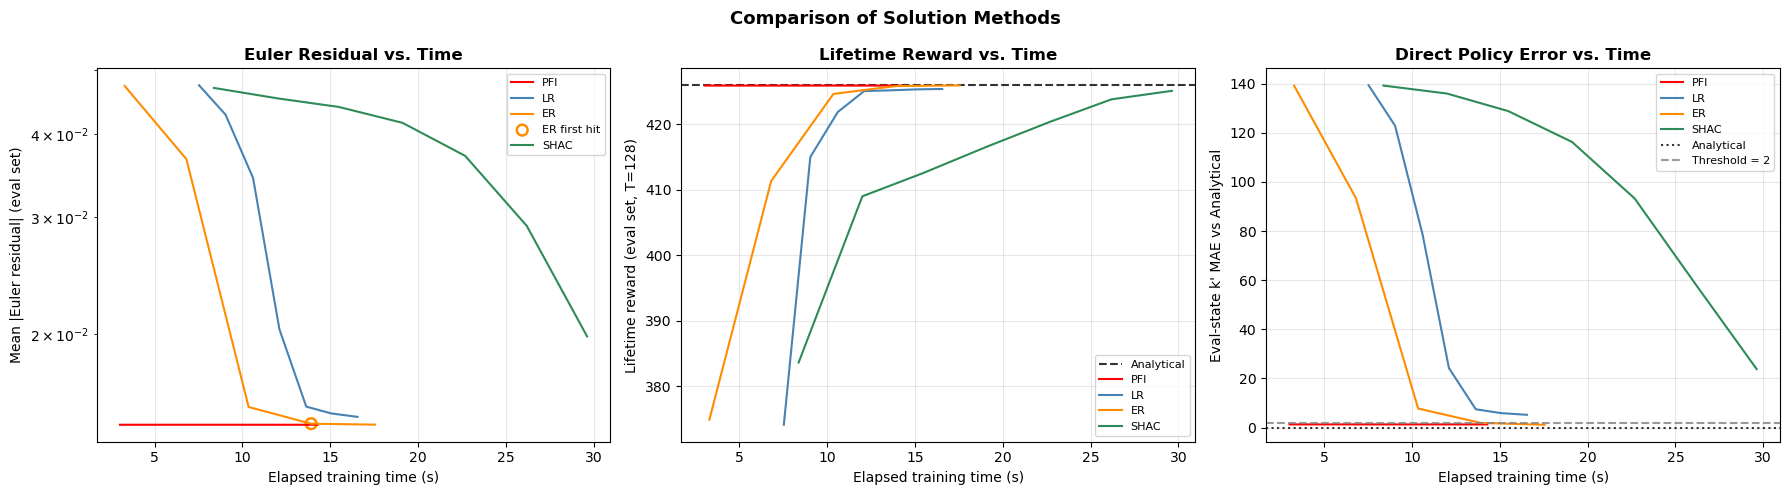

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for name, entry in results.items():
    m = entry.get("checkpoint_metrics") or entry.get("result", {}).get("history", {})
    if not m or "elapsed_sec" not in m or "euler_residual_val" not in m:
        continue
    ax.plot(m["elapsed_sec"], m["euler_residual_val"], color=METHOD_COLORS[name], lw=1.5, label=name)
    if name in TRAINED_METHODS:
        add_hit_marker(ax, entry, m["euler_residual_val"], METHOD_COLORS[name], f"{name} first hit")
ax.set_xlabel("Elapsed training time (s)")
ax.set_ylabel("Mean |Euler residual| (eval set)")
ax.set_title("Euler Residual vs. Time", fontweight="bold")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(analytic_value, color="black", lw=1.5, ls="--", alpha=0.8, label="Analytical")
for name, entry in results.items():
    m = entry.get("checkpoint_metrics") or entry.get("result", {}).get("history", {})
    if not m or "elapsed_sec" not in m or "lifetime_reward_val" not in m:
        continue
    ax.plot(m["elapsed_sec"], m["lifetime_reward_val"], color=METHOD_COLORS[name], lw=1.5, label=name)
ax.set_xlabel("Elapsed training time (s)")
ax.set_ylabel(f"Lifetime reward (eval set, T={EVAL_HORIZON})")
ax.set_title("Lifetime Reward vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
for name, entry in results.items():
    m = entry.get("checkpoint_metrics") or entry.get("result", {}).get("history", {})
    if not m or "elapsed_sec" not in m or "policy_mae" not in m:
        continue
    ax.plot(m["elapsed_sec"], m["policy_mae"], color=METHOD_COLORS[name], lw=1.5, label=name)
ax.axhline(0.0, color="black", lw=1.5, ls=":", alpha=0.8, label="Analytical")
ax.set_xlabel("Elapsed training time (s)")
ax.set_ylabel("Eval-state k' MAE vs Analytical")
ax.set_title("Direct Policy Error vs. Time", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

_panel_for_metric = {"euler_residual_val": 0, "lifetime_reward_val": 1, "policy_mae": 2}
if _monitor in _panel_for_metric:
    axes[_panel_for_metric[_monitor]].axhline(
        CONVERGENCE_THRESHOLD, color="gray", lw=1.5, ls="--", alpha=0.8,
        label=f"Threshold = {CONVERGENCE_THRESHOLD:.4g}")
    axes[_panel_for_metric[_monitor]].legend(fontsize=8)

fig.suptitle("Comparison of Solution Methods", fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "convergence_curves.png")
plt.show()


## 6.2 Policy Slice Validation


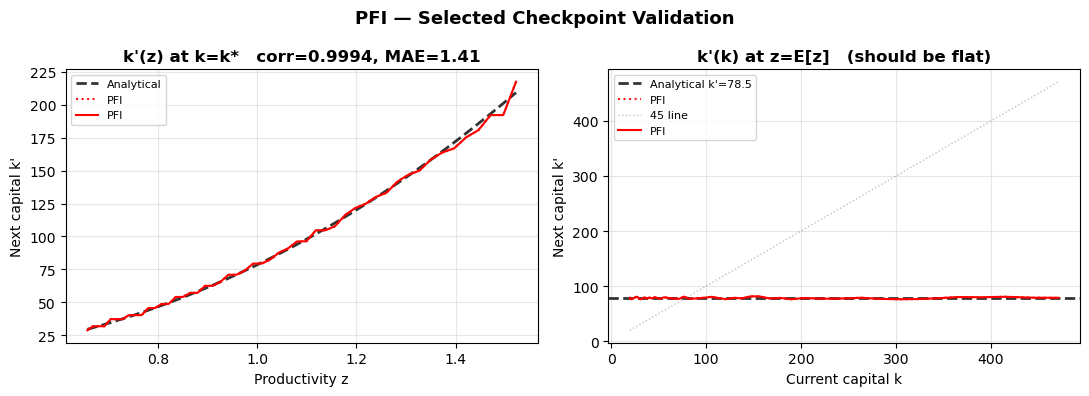

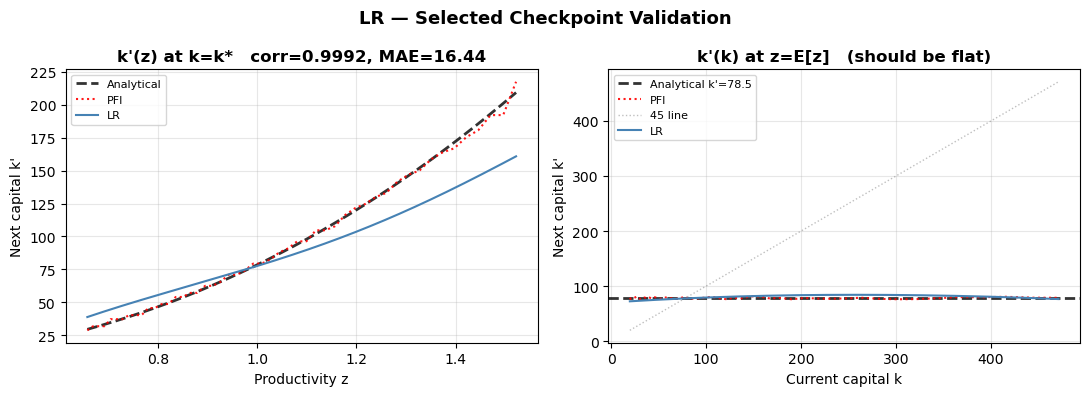

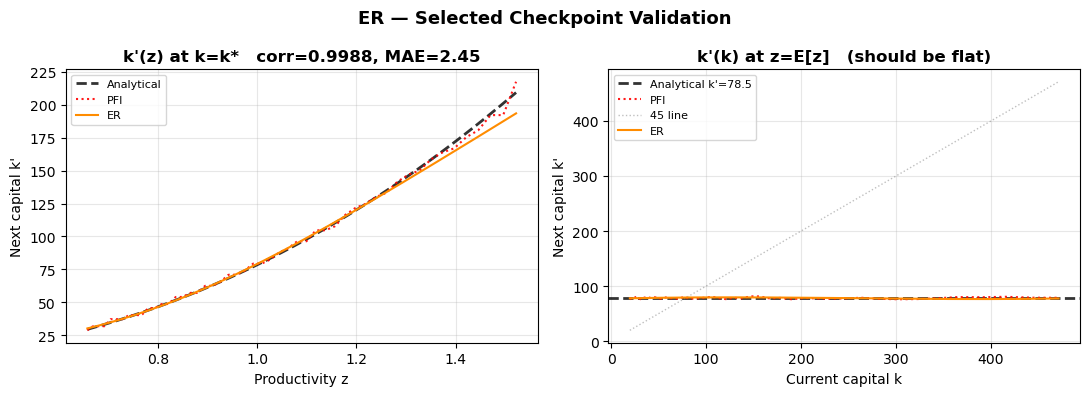

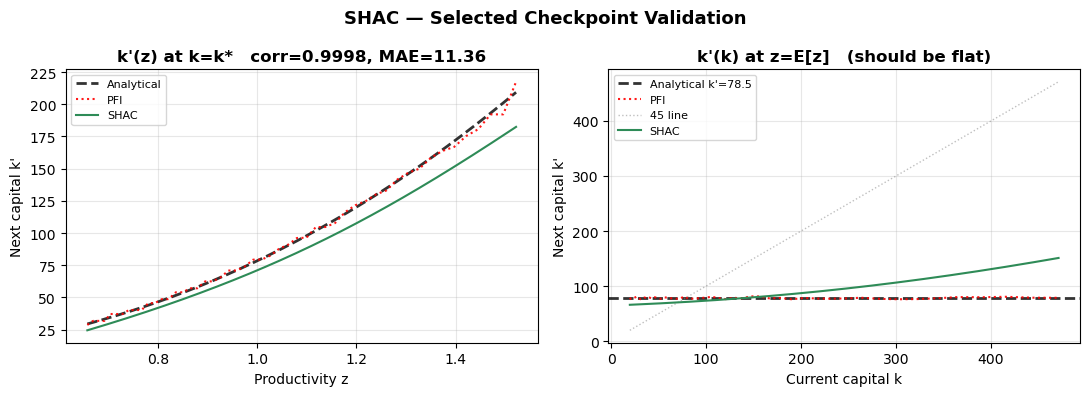

In [20]:
validate_single("PFI", pfi_kpz, pfi_kpk, METHOD_COLORS["PFI"], pfi_kpz, pfi_kpk,
                save_name="policy_validation_pfi.png")

for name in TRAINED_METHODS:
    kp_z, kp_k = get_policy_slices(results[name]["policy"])
    validate_single(
        name, kp_z, kp_k, METHOD_COLORS[name], pfi_kpz, pfi_kpk,
        save_name=f"policy_validation_{name.lower()}.png",
    )


## 6.3 All Methods Overlay


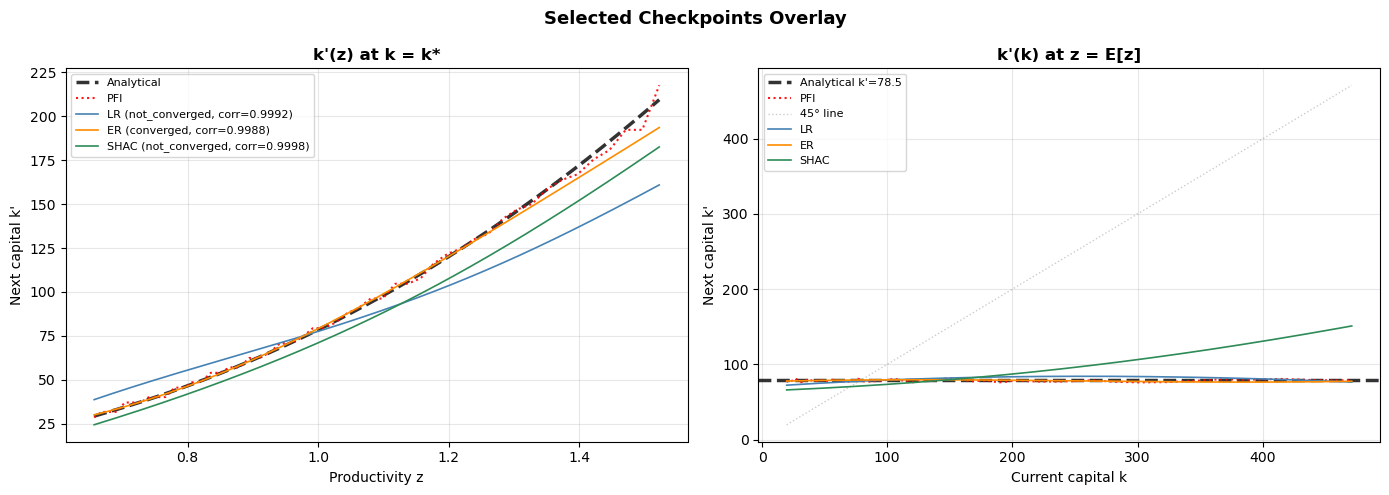

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(z_grid, kp_analytical_z, "k--", lw=2.5, alpha=0.8, label="Analytical")
ax.plot(z_grid, pfi_kpz, color=METHOD_COLORS["PFI"], lw=1.5, ls=":", alpha=0.9, label="PFI")
for name in TRAINED_METHODS:
    kp_z, _ = get_policy_slices(results[name]["policy"])
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    ax.plot(z_grid, kp_z, color=METHOD_COLORS[name], lw=1.2,
            label=f"{name} ({results[name]['selected']['status']}, corr={corr:.4f})")
ax.set_title("k'(z) at k = k*", fontweight="bold")
ax.set_xlabel("Productivity z")
ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(kp_analytical_ss, color="k", ls="--", lw=2.5,
           alpha=0.8, label=f"Analytical k'={kp_analytical_ss:.1f}")
ax.plot(k_grid, pfi_kpk, color=METHOD_COLORS["PFI"], lw=1.5, ls=":", alpha=0.9, label="PFI")
ax.plot(k_grid, k_grid, ":", color="gray", lw=1, alpha=0.4, label="45° line")
for name in TRAINED_METHODS:
    _, kp_k = get_policy_slices(results[name]["policy"])
    ax.plot(k_grid, kp_k, color=METHOD_COLORS[name], lw=1.2, label=name)
ax.set_title("k'(k) at z = E[z]", fontweight="bold")
ax.set_xlabel("Current capital k")
ax.set_ylabel("Next capital k'")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("Selected Checkpoints Overlay", fontweight="bold", fontsize=13)
plt.tight_layout()
persist_figure(fig, "selected_checkpoints_overlay.png")
plt.show()


## 6.4 Accuracy Summary


In [22]:
header = "Method | Status          | Corr(k'z)  | MAE(k'z)  | MAE(k'k)  | Euler Res  | Lifetime V | Analytic k' MAE | Cost(s)"
print(header)
print("-" * len(header))

summary_rows = []

corr_pfi = np.corrcoef(pfi_kpz, kp_analytical_z)[0, 1]
mae_z_pfi = np.mean(np.abs(pfi_kpz - kp_analytical_z))
mae_k_pfi = np.mean(np.abs(pfi_kpk - kp_analytical_ss))
print(
    f"{'PFI':>6s} | {'grid-benchmark':<15s} | {corr_pfi:10.6f} | {mae_z_pfi:9.3f} | {mae_k_pfi:9.3f} | "
    f"{results['PFI']['selected']['selected_euler']:10.6f} | {results['PFI']['selected']['selected_value']:9.2f} | "
    f"{results['PFI']['selected']['selected_analytic_mae']:15.4f} | {results['PFI']['selected']['wall_time_sec']:7.1f}"
)
summary_rows.append({
    "method": "PFI",
    "status": "grid-benchmark",
    "corr_kprime_z": corr_pfi,
    "mae_kprime_z": mae_z_pfi,
    "mae_kprime_k": mae_k_pfi,
    "euler_residual": results['PFI']['selected']['selected_euler'],
    "lifetime_reward_val": results['PFI']['selected']['selected_value'],
    "analytic_kprime_mae": results['PFI']['selected']['selected_analytic_mae'],
    "cost_sec": results['PFI']['selected']['wall_time_sec'],
})

for name in TRAINED_METHODS:
    kp_z, kp_k = get_policy_slices(results[name]["policy"])
    corr = np.corrcoef(kp_z, kp_analytical_z)[0, 1]
    mae_z = np.mean(np.abs(kp_z - kp_analytical_z))
    mae_k = np.mean(np.abs(kp_k - kp_analytical_ss))
    sel = results[name]["selected"]
    print(
        f"{name:>6s} | {sel['status']:<15s} | {corr:10.6f} | {mae_z:9.3f} | {mae_k:9.3f} | "
        f"{sel['selected_euler']:10.6f} | {sel['selected_value']:9.2f} | {sel['selected_analytic_mae']:15.4f} | "
        f"{sel['wall_time_sec']:7.1f}"
    )
    summary_rows.append({
        "method": name,
        "status": sel["status"],
        "corr_kprime_z": corr,
        "mae_kprime_z": mae_z,
        "mae_kprime_k": mae_k,
        "euler_residual": sel["selected_euler"],
        "lifetime_reward_val": sel["selected_value"],
        "analytic_kprime_mae": sel["selected_analytic_mae"],
        "cost_sec": sel["wall_time_sec"],
    })

save_summary_rows(RUN, summary_rows, filename="summary.csv")


Method | Status          | Corr(k'z)  | MAE(k'z)  | MAE(k'k)  | Euler Res  | Lifetime V | Analytic k' MAE | Cost(s)
-------------------------------------------------------------------------------------------------------------------
   PFI | grid-benchmark  |   0.999433 |     1.411 |     1.157 |   0.014596 |    425.86 |          1.3138 |    15.3
    LR | not_converged   |   0.999236 |    16.442 |     3.401 |   0.015001 |    425.34 |          5.2196 |    16.5
    ER | converged       |   0.998778 |     2.447 |     1.079 |   0.014601 |    425.89 |          1.1700 |    18.0
  SHAC | not_converged   |   0.999760 |    11.357 |    24.916 |   0.019832 |    425.06 |         23.8326 |    29.6
